# Chapter 4: Housing price regression

## Section 1: Define and inspect the problem

### one small step: load the data and inspect what one input and target look like.

MNIST, IMDB, and Reuters predicted categories. This model predicts a
number: the median home value for a location.

Each observation has 13 numerical features. Its target is one value,
expressed in thousands of dollars in this historical dataset.

$$
x_i \in \mathbb{R}^{13},
\qquad
y_i \in \mathbb{R}
$$

The goal is to learn a function that maps the features to a predicted value:

$$
\hat{y}_i = f_\theta(x_i)
$$

For example, a target of 25.0 represents $25,000 in the dataset's
historical dollar units. It is a median value for a location, not the
sale price of an individual house.

First, inspect the data as loaded. We will prepare the features for
training in the next section.

In [1]:
from tensorflow.keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) = (
    boston_housing.load_data()
)

print("Training inputs:", train_data.shape)
print("Training targets:", train_targets.shape)
print("Test inputs:", test_data.shape)
print("Test targets:", test_targets.shape)

print("\nFirst input, 13 features:")
print(train_data[0])

print("\nFirst target, in thousands of dollars:")
print(train_targets[0])

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
Training inputs: (404, 13)
Training targets: (404,)
Test inputs: (102, 13)
Test targets: (102,)

First input, 13 features:
[  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]

First target, in thousands of dollars:
15.2


One context note for this book example: Keras cautions against using the Boston dataset for general applications because one of its features encodes a problematic racial assumption. We’ll use it to understand Chollet’s regression workflow, then use a better dataset when we apply the method elsewhere.

## Section 2: Normalize the input features

### Normalize the 13 features. The feature columns use different scales, so we’ll express each one relative to its training-set mean and standard deviation.

The 13 features have different numerical ranges. For each feature
column $j$, calculate its mean and standard deviation using only
the training observations:

$$
\mu_j = \operatorname{mean}(X_{\mathrm{train},j})
$$

$$
\sigma_j = \operatorname{std}(X_{\mathrm{train},j})
$$

Then transform each value:

$$
x'_{i,j} = \frac{x_{i,j} - \mu_j}{\sigma_j}
$$

This gives the training feature columns means near 0 and standard
deviations near 1.

Apply the **same training means and standard deviations** to the
test inputs. The test set must not determine how we prepare inputs.

The price targets remain in thousands of dollars; we normalize
the input features only.

In [2]:
import numpy as np

feature_means = train_data.mean(axis=0)
feature_stds = train_data.std(axis=0)

x_train = ((train_data - feature_means) / feature_stds).astype("float32")
x_test = ((test_data - feature_means) / feature_stds).astype("float32")

print("Raw first observation, first 5 features:")
print(train_data[0, :5])

print("\nNormalized first observation, first 5 features:")
print(x_train[0, :5])

print("\nNormalized shapes:")
print("Training:", x_train.shape)
print("Test:", x_test.shape)

print("\nTraining column means (rounded):")
print(np.round(x_train.mean(axis=0), 2))

print("\nTraining column standard deviations (rounded):")
print(np.round(x_train.std(axis=0), 2))

Raw first observation, first 5 features:
[1.23247 0.      8.14    0.      0.538  ]

Normalized first observation, first 5 features:
[-0.27224633 -0.48361546 -0.4357616  -0.25683275 -0.16522661]

Normalized shapes:
Training: (404, 13)
Test: (102, 13)

Training column means (rounded):
[-0.  0.  0. -0.  0.  0. -0.  0. -0. -0. -0. -0. -0.]

Training column standard deviations (rounded):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The shapes should remain (404, 13) and (102, 13). The training column means should be close to 0, and their standard deviations close to 1. An individual normalized value can be negative or greater than 1; this transformation does not confine values to the interval [0, 1].
Next, we’ll build a network whose output is one predicted price.

## Section 3: Build the regression network

### Build the regression network. Its output is one predicted value in thousands of dollars.

The architecture is:

$$
13 \rightarrow 64 \rightarrow 64 \rightarrow 1
$$

For one observation:

$$
h_1 = \operatorname{ReLU}(W_1x + b_1)
$$

$$
h_2 = \operatorname{ReLU}(W_2h_1 + b_2)
$$

$$
\hat{y} = W_3h_2 + b_3
$$

The 13 input values are the normalized features. The two hidden
layers each contain 64 neurons. The final layer has one neuron
because we want one predicted price.

The final layer has no activation function: its output is a
numerical estimate, rather than a class probability.

Building the network initializes its weights and biases. It has
not learned from the housing observations yet.

In [3]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
    return keras.Sequential([
        keras.Input(shape=(13,)),
        layers.Dense(64, activation="relu", name="hidden_1"),
        layers.Dense(64, activation="relu", name="hidden_2"),
        layers.Dense(1, name="predicted_price")
    ])

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_price (Dense)         │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

The summary should show 5,122 trainable parameters:
- First layer: 13 × 64 + 64 = 896
- Second layer: 64 × 64 + 64 = 4,160
- Output layer: 64 × 1 + 1 = 65
That adds to 5,121, so let me correct the expected total explicitly: 5,121 trainable parameters. The first layer has 896 parameters. We defined build_model() because later, with this small dataset, we’ll need fresh models for separate validation runs.

Next, we’ll choose a loss and metric that measure error in a numerical prediction.

## Section 4: Choose a regression loss and metric

### Compile the housing model. Since the target is a number, we’ll measure the size of prediction errors rather than classification accuracy.

For observation $i$, the prediction error is:

$$
e_i = \hat{y}_i - y_i
$$

We use mean squared error (MSE) as the training loss:

$$
\operatorname{MSE}
=
\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

Squaring makes larger errors count more strongly.

We also report mean absolute error (MAE):

$$
\operatorname{MAE}
=
\frac{1}{n}\sum_{i=1}^{n}|\hat{y}_i-y_i|
$$

The targets are in thousands of dollars, so MAE is in
thousands of dollars too. An MAE of 3 would mean an average
absolute error of about $3,000 in this historical dataset.

RMSprop will use gradients of MSE to update the model's weights
during training. Compiling configures this process; it does not
train the model.

In [4]:
model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)

print("Housing regression model compiled.")

Housing regression model compiled.


The network from Section 3 has 5,121 parameters; the corrected total at the end of that section was the right one. Next, we’ll address the unusual challenge here: only 404 training observations, which makes a single small validation split unreliable.

## Section 5: Prepare four-fold validation

### Prepare four validation folds. With only 404 training observations, each fold will reserve 101 for validation and use the other 303 for training.
There is one detail to correct from our earlier preprocessing step: x_train was normalized using all 404 observations, which is fine for the final model. During fold validation, we must calculate the mean and standard deviation from that fold’s 303 training observations so its 101 validation observations do not influence preprocessing.

Divide the 404 training observations into four groups of 101.

For each validation run:

- Hold out one group of 101 observations.
- Train on the other 303 observations.
- Measure error on the held-out group.

Each observation serves as validation data once.

Within each run, calculate the feature means and standard deviations
from its 303 training observations. Apply those same values to its
101 validation observations.

The separate 102-observation test set remains reserved for final
evaluation.

In [5]:
import numpy as np

number_of_folds = 4

indices = np.arange(len(train_data))
rng = np.random.default_rng(42)
rng.shuffle(indices)

folds = np.array_split(indices, number_of_folds)

def make_fold_data(validation_fold):
    validation_indices = folds[validation_fold]
    training_indices = np.concatenate([
        folds[j]
        for j in range(number_of_folds)
        if j != validation_fold
    ])

    raw_fold_train = train_data[training_indices]
    raw_fold_val = train_data[validation_indices]

    fold_means = raw_fold_train.mean(axis=0)
    fold_stds = raw_fold_train.std(axis=0)

    fold_x_train = (
        (raw_fold_train - fold_means) / fold_stds
    ).astype("float32")
    fold_x_val = (
        (raw_fold_val - fold_means) / fold_stds
    ).astype("float32")

    fold_y_train = train_targets[training_indices]
    fold_y_val = train_targets[validation_indices]

    return fold_x_train, fold_y_train, fold_x_val, fold_y_val

fold_x_train, fold_y_train, fold_x_val, fold_y_val = make_fold_data(0)

print("Fold 1 training inputs:", fold_x_train.shape)
print("Fold 1 training targets:", fold_y_train.shape)
print("Fold 1 validation inputs:", fold_x_val.shape)
print("Fold 1 validation targets:", fold_y_val.shape)

Fold 1 training inputs: (303, 13)
Fold 1 training targets: (303,)
Fold 1 validation inputs: (101, 13)
Fold 1 validation targets: (101,)


Expected shapes are (303, 13), (303,), (101, 13), and (101,). This cell prepares the splits; it does not train a model. Next, we’ll train one fresh model per fold and collect each fold’s validation MAE.

## Section 6: Run four-fold validation

### Train and validate four fresh models. Each fold gets a new model, so learning in one fold cannot carry into the next.

For each of the four folds:

1. Prepare its training and validation observations.
2. Create a fresh 13 → 64 → 64 → 1 network.
3. Train for 100 epochs.
4. Record validation MAE after every epoch.

We will average the four validation histories to choose a
reasonable training duration.

MAE is measured in thousands of dollars. For example, an MAE
of 3.5 corresponds to an average absolute error of about $3,500
in this historical dataset.

In [6]:
all_mae_histories = []

for validation_fold in range(number_of_folds):
    fold_x_train, fold_y_train, fold_x_val, fold_y_val = (
        make_fold_data(validation_fold)
    )

    fold_model = build_model()
    fold_model.compile(
        optimizer="rmsprop",
        loss="mse",
        metrics=["mae"]
    )

    fold_history = fold_model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=100,
        batch_size=16,
        verbose=0
    )

    mae_history = fold_history.history["val_mae"]
    all_mae_histories.append(mae_history)

    print(
        f"Fold {validation_fold + 1}: "
        f"validation MAE after epoch 100 = {mae_history[-1]:.2f}"
    )

print("Number of folds:", len(all_mae_histories))
print("Epochs recorded per fold:", len(all_mae_histories[0]))

Fold 1: validation MAE after epoch 100 = 2.40
Fold 2: validation MAE after epoch 100 = 2.72
Fold 3: validation MAE after epoch 100 = 2.03
Fold 4: validation MAE after epoch 100 = 2.33
Number of folds: 4
Epochs recorded per fold: 100


Expect Number of folds: 4 and Epochs recorded per fold: 100. The four MAE values will differ because each fold holds out different observations and each model starts with new weights.
The printed epoch 100 values do not yet tell us which epoch to choose. Next, we’ll average the four histories and plot validation MAE across the 100 epochs.

## Section 7: Average the validation results

### Average and plot validation MAE. This lets us see the training duration that worked best across all four held-out groups.

At each epoch $e$, average validation MAE across the four folds:

$$
\overline{\mathrm{MAE}}_e
=
\frac{1}{4}
\sum_{k=1}^{4}\mathrm{MAE}_{k,e}
$$

A lower validation MAE means smaller average prediction errors
on held-out observations.

The curve may be uneven because this dataset is small. We will
inspect the overall pattern as well as the epoch with the
lowest recorded average.

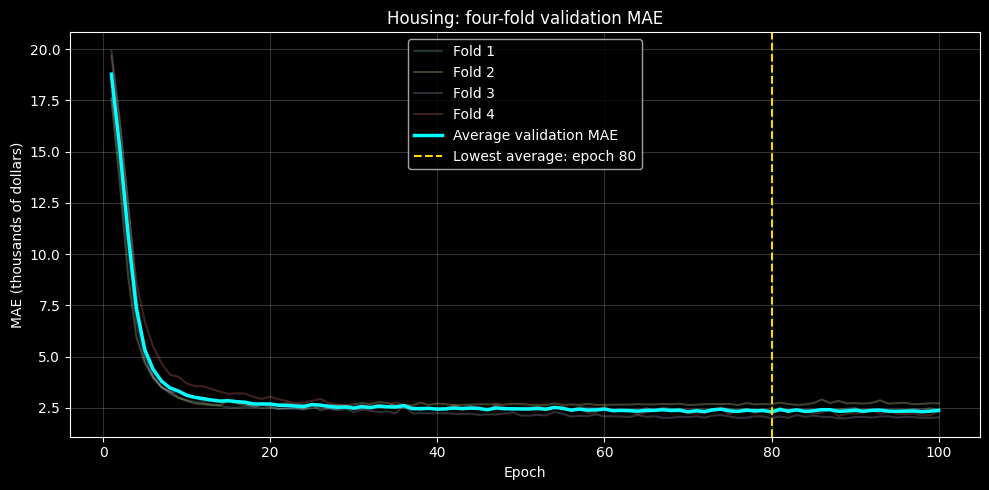

Epoch with lowest average validation MAE: 80
Lowest average validation MAE: 2.3


In [7]:
import matplotlib.pyplot as plt

mae_by_fold = np.asarray(all_mae_histories)
average_mae_history = mae_by_fold.mean(axis=0)
epochs = np.arange(1, len(average_mae_history) + 1)

best_epoch = int(np.argmin(average_mae_history)) + 1

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(10, 5))

    for fold_number, fold_mae in enumerate(mae_by_fold, start=1):
        ax.plot(
            epochs, fold_mae,
            alpha=0.25,
            label=f"Fold {fold_number}"
        )

    ax.plot(
        epochs, average_mae_history,
        color="cyan", linewidth=2.5,
        label="Average validation MAE"
    )
    ax.axvline(
        best_epoch, color="gold", linestyle="--",
        label=f"Lowest average: epoch {best_epoch}"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE (thousands of dollars)")
    ax.set_title("Housing: four-fold validation MAE")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

print("Epoch with lowest average validation MAE:", best_epoch)
print(
    "Lowest average validation MAE:",
    round(float(average_mae_history[best_epoch - 1]), 2)
)

The faint lines show individual folds; the cyan line is their average. If the minimum is a sharp isolated dip, treat the exact epoch cautiously and look for the broader low-error region. Next, we’ll train a fresh final model on all 404 training observations and then evaluate it on the 102 test observations.

## Section 8: Train on all 404 observations

### Train the final housing model. The four folds gave us a training duration. Now we’ll create a fresh network and train it using all 404 training observations.

Four-fold validation gave us `best_epoch` as an estimate of
how long to train.

Create a fresh model with the same architecture, then train it
on all 404 training observations:

$$
X_{\mathrm{train}} \in \mathbb{R}^{404 \times 13}
$$

$$
y_{\mathrm{train}} \in \mathbb{R}^{404}
$$

Use `x_train`, which was normalized using statistics from all
404 training observations. The test inputs in `x_test` were
transformed using those same statistics.

The final model has newly initialized weights. Its training MAE
will not necessarily match the four-fold validation MAE.

In [8]:
final_model = build_model()

final_model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)

final_history = final_model.fit(
    x_train,
    train_targets,
    epochs=best_epoch,
    batch_size=16,
    verbose=0
)

print("Training observations:", x_train.shape[0])
print("Epochs completed:", len(final_history.history["loss"]))
print(
    "Final training MAE:",
    round(float(final_history.history["mae"][-1]), 2)
)

Training observations: 404
Epochs completed: 80
Final training MAE: 1.69


You should see Training observations: 404, and the epoch count should equal best_epoch. The printed MAE describes the training data. Next, we’ll measure prediction error on the 102 reserved test observations.

## Section 9: Evaluate on the test set

### Evaluate the final model on the 102 reserved observations.

The test observations were not used to fit model weights or
choose the number of training epochs.

$$
X_{\mathrm{test}} \in \mathbb{R}^{102 \times 13},
\qquad
y_{\mathrm{test}} \in \mathbb{R}^{102}
$$

Test MSE is the average squared prediction error.

Test MAE is the average absolute prediction error, measured in
thousands of dollars in this historical dataset.

In [9]:
test_mse, test_mae = final_model.evaluate(
    x_test,
    test_targets,
    verbose=0
)

print(f"Test MSE: {test_mse:.2f}")
print(f"Test MAE: {test_mae:.2f} thousand dollars")
print(f"Approximate historical-dollar MAE: ${test_mae * 1000:,.0f}")

Test MSE: 19.27
Test MAE: 2.69 thousand dollars
Approximate historical-dollar MAE: $2,687


For example, if the output is Test MAE: 3.20 thousand dollars, the model’s predictions differ from the recorded median values by $3,200 on average in the dataset’s historical dollar units. It does not mean every prediction is within $3,200.
Next, we’ll inspect one prediction beside its recorded value and calculate its individual error.

## Section 10: Inspect an individual prediction

### Inspect one housing prediction. This connects the model’s single output to an actual target and an error measured in dollars.

For one location, the model returns one estimated median value:

$$
\hat{y}_i = f_\theta(x_i)
$$

Its signed error is:

$$
e_i = \hat{y}_i - y_i
$$

A positive error means the model predicted above the recorded
value. A negative error means it predicted below it.

Its absolute error is $|e_i|$. Both values are in thousands
of historical dollars.

In [10]:
observation_index = 0

one_input = x_test[observation_index:observation_index + 1]
prediction = final_model.predict(one_input, verbose=0)

predicted_value = float(prediction[0, 0])
actual_value = float(test_targets[observation_index])

signed_error = predicted_value - actual_value
absolute_error = abs(signed_error)

print("Input shape:", one_input.shape)
print("Prediction shape:", prediction.shape)
print(f"Predicted median value: ${predicted_value * 1000:,.0f}")
print(f"Recorded median value:  ${actual_value * 1000:,.0f}")
print(f"Signed error:           ${signed_error * 1000:+,.0f}")
print(f"Absolute error:         ${absolute_error * 1000:,.0f}")

Input shape: (1, 13)
Prediction shape: (1, 1)
Predicted median value: $10,017
Recorded median value:  $7,200
Signed error:           $+2,817
Absolute error:         $2,817


The shapes should be (1, 13) for the input batch and (1, 1) for the output. Your prediction will depend on the model you trained.
The individual absolute error here is for one location. The test MAE from Section 9 averages absolute errors across all 102 test locations. Next, we’ll compare all four Chapter 2–4 examples through the same input, target, output, and loss blueprint.

## Section 11: Compare the four learning problems

### Put the four examples into one model-design blueprint. Add this final Markdown cell to the housing notebook:

| Example | Numerical input for one observation | Target | Output layer | Training loss |
| --- | --- | --- | --- | --- |
| MNIST | 784 scaled pixels | Integer digit, 0–9 | 10 softmax probabilities | Sparse categorical cross-entropy |
| IMDB | 10,000 token-presence values | Binary label, 0 or 1 | 1 sigmoid probability | Binary cross-entropy |
| Reuters | 10,000 token-presence values | 46-entry one-hot vector | 46 softmax probabilities | Categorical cross-entropy |
| Housing | 13 normalized features | One numerical value | 1 linear value | Mean squared error |

### Shared model-design steps

1. Identify one raw observation, $r_i$, and its correct target, $y_i$.
2. Prepare a numerical input, $x_i = P(r_i)$.
3. Choose an output shape that matches what must be predicted.
4. Choose a target encoding and loss that work with that output.
5. Train the model and use validation results to guide choices.
6. Evaluate once on the reserved test set.

The central calculation is the same:

$$
\hat{y}_i = f_\theta(x_i)
$$

What changes is the **meaning of $\hat{y}_i$**:

- MNIST: a vector of 10 digit probabilities.
- IMDB: one positive-review probability.
- Reuters: a vector of 46 topic probabilities.
- Housing: one estimated numerical value.

### Validation with different dataset sizes

For IMDB and Reuters, we held aside part of the training data
for validation.

Housing had only 404 training observations, so we used four-fold
validation. Each fold trained a fresh model and held out a different
group of 101 observations.

### What an error means

Classification accuracy counts correct class choices.
Regression MAE measures the average size of numerical errors.

Housing MAE is expressed in thousands of dollars from the
historical dataset. It is not a present-day home-price estimate.

That completes the four introductory notebooks: MNIST, IMDB, Reuters, and housing. The next planned lesson is the TensorFlow.js bridge: we’ll choose one trained model, save it, and work out how the browser must reproduce its input preparation before making predictions.